# 05 · Comparison of the four models

**Owner:** Tanishq Sharma  
Common protocol: de Chazal DS1/DS2 inter-patient split, same preprocessed beats, same metric code (`src/evaluate.py`), mean ± std over seeds 42/43/44. Script: `src/compare.py`.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
!cd .. && python src/compare.py > /dev/null
from IPython.display import Markdown, Image, display
display(Markdown(open(os.path.join(ROOT, "results", "comparison.md")).read()))

zsh:1: command not found: python


# Model comparison on DS2 (inter-patient test set)

Mean ± standard deviation over seeds 42, 43, 44. Macro averages over the five AAMI classes unless marked N/S/V/F.

| Model | Accuracy | Macro precision | Macro recall | Macro-F1 | Macro-F1 (N/S/V/F) |
|---|---|---|---|---|---|
| M1 Random Forest | 0.939 ± 0.000 | 0.518 ± 0.003 | 0.358 ± 0.001 | 0.371 ± 0.001 | 0.463 ± 0.001 |
| M2 1D CNN (DE/PSO-tuned) | 0.893 ± 0.041 | 0.429 ± 0.030 | 0.404 ± 0.015 | 0.360 ± 0.056 | 0.449 ± 0.070 |
| M3 BiGRU | 0.891 ± 0.005 | 0.323 ± 0.013 | 0.360 ± 0.010 | 0.333 ± 0.010 | 0.416 ± 0.012 |
| M4 Transformer | 0.904 ± 0.031 | 0.413 ± 0.066 | 0.409 ± 0.004 | 0.392 ± 0.033 | 0.489 ± 0.043 |
| M2 1D CNN (untuned default) | 0.927 ± 0.011 | 0.416 ± 0.033 | 0.405 ± 0.038 | 0.386 ± 0.048 | 0.482 ± 0.060 |

## Per-class recall (sensitivity)

| Model | N | S | V | F | Q |
|---|---|---|---|---|---|
| M1 Random Forest | 0.998 | 0.014 | 0.779 | 0.000 | 0.000 |
| M2 1D CNN (DE/PSO-tuned) | 0.929 | 0.123 | 0.938 | 0.027 | 0.000 |
| M3 BiGRU | 0.939 | 0.026 | 0.827 | 0.009 | 0.000 |
| M4 Transformer | 0.944 | 0.197 | 0.857 | 0.001 | 0.048 |
| M2 1D CNN (untuned default) | 0.970 | 0.158 | 0.898 | 0.000 | 0.000 |

## Per-class F1

| Model | N | S | V | F | Q |
|---|---|---|---|---|---|
| M1 Random Forest | 0.967 | 0.027 | 0.859 | 0.000 | 0.000 |
| M2 1D CNN (DE/PSO-tuned) | 0.950 | 0.184 | 0.647 | 0.018 | 0.000 |
| M3 BiGRU | 0.946 | 0.040 | 0.674 | 0.005 | 0.000 |
| M4 Transformer | 0.948 | 0.254 | 0.753 | 0.001 | 0.006 |
| M2 1D CNN (untuned default) | 0.967 | 0.171 | 0.790 | 0.000 | 0.000 |

DS2 support: N 44228, S 1836, V 3220, F 388, Q 7


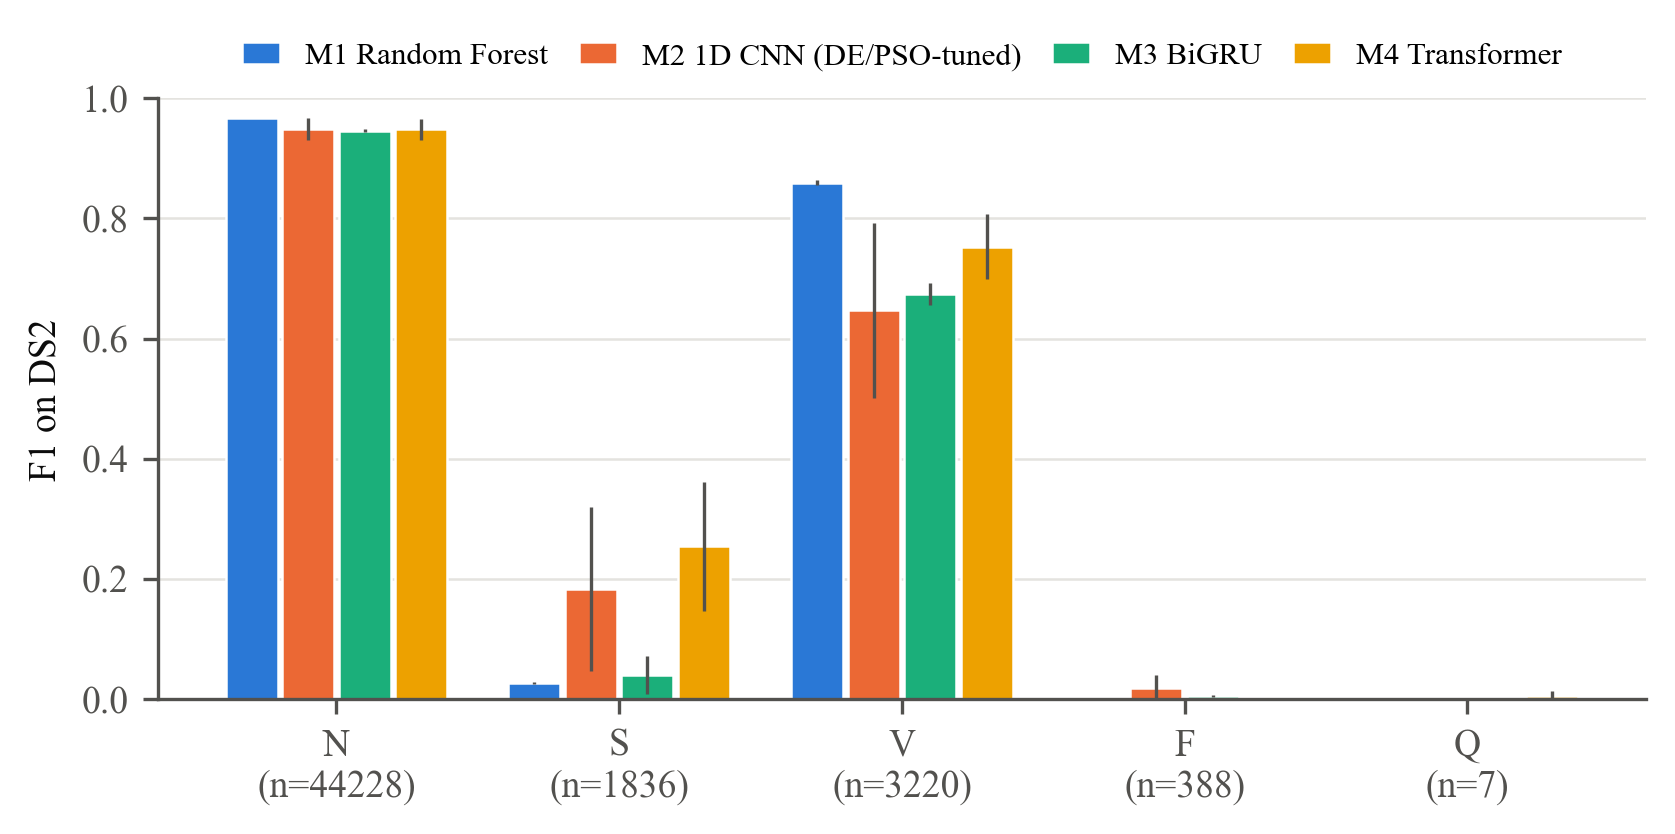

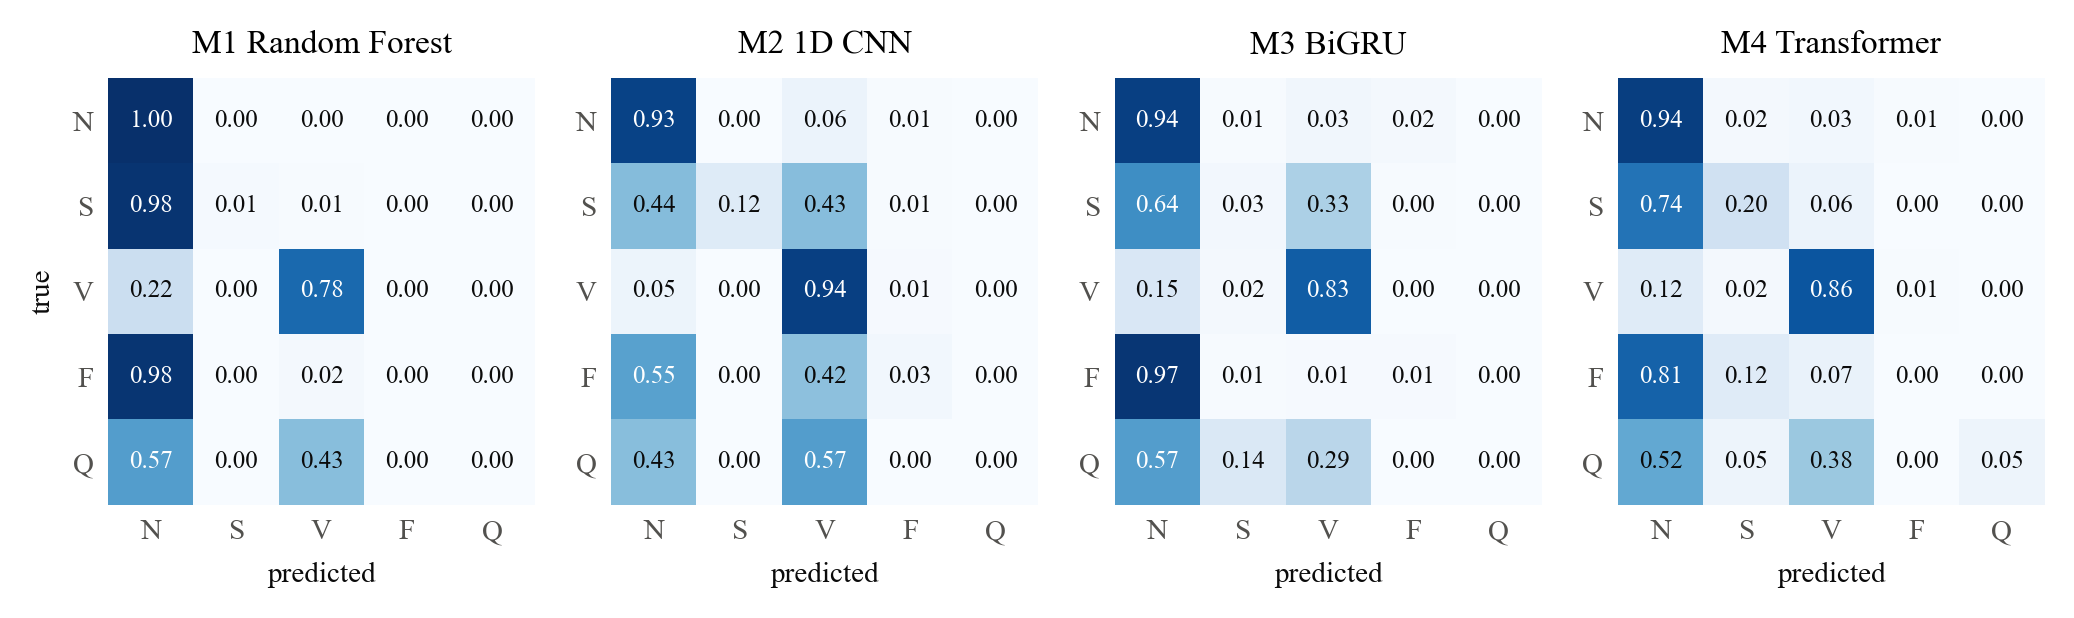

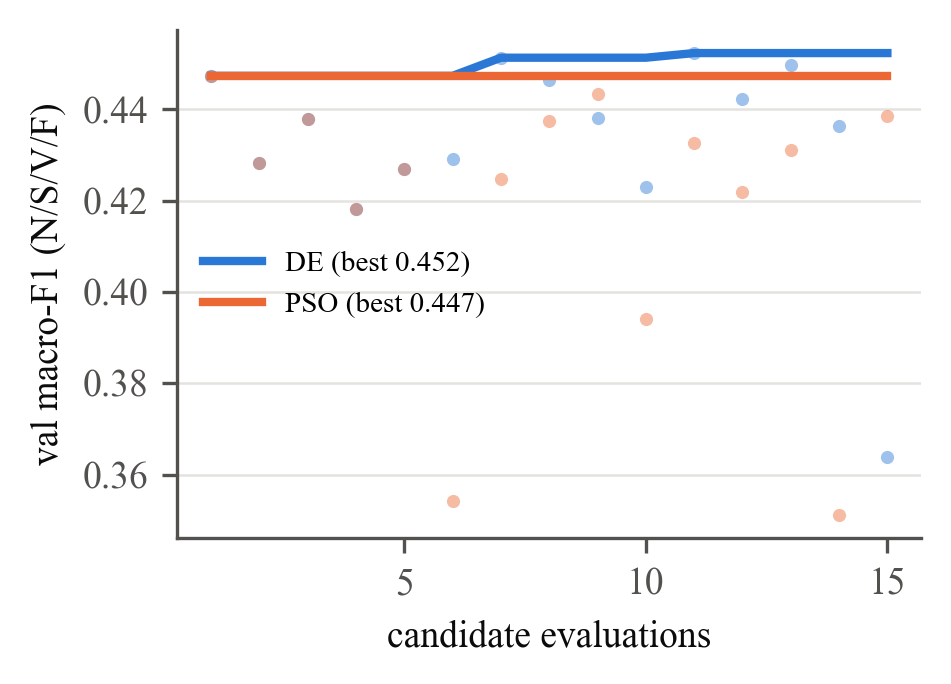

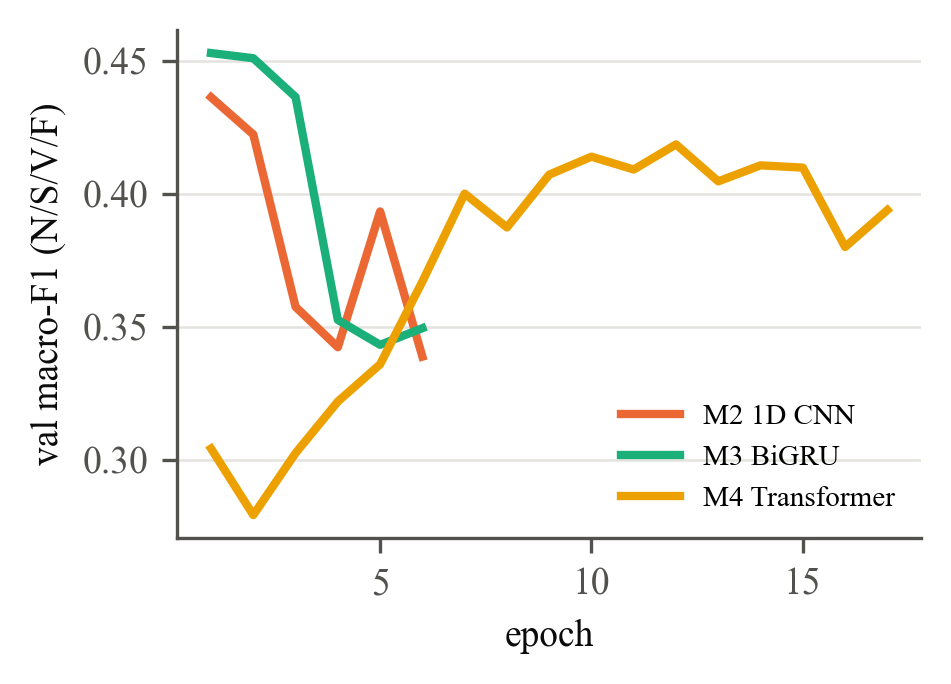

In [3]:
for f in ["per_class_f1", "confusion_matrices", "cnn_search", "learning_curves"]:
    display(Image(os.path.join(ROOT, "figures", f + ".png"), width=700))

## Patient-level bootstrap 95% confidence intervals
The 22 DS2 records are resampled with replacement (2,000 draws, `src/bootstrap_ci.py`). Resampling beats instead would understate the uncertainty, because 75% of DS2 S beats come from record 232 and 93% of F beats from record 213.

In [4]:
ci = json.load(open(os.path.join(ROOT, 'results', 'bootstrap_ci.json')))
print(f"{'model':18s} macro-F1   95% CI")
for tag, r in ci['models'].items():
    m = r['macro_f1']
    print(f"{tag:18s} {m['point']:.3f}    [{m['ci95'][0]:.3f}, {m['ci95'][1]:.3f}]")
print('All intervals overlap: no model is statistically better on 22 test patients.')

model              macro-F1   95% CI
m1_random_forest   0.371    [0.339, 0.418]
m2_cnn1d_tuned     0.360    [0.313, 0.405]
m3_bigru           0.333    [0.279, 0.376]
m4_transformer     0.392    [0.333, 0.423]
m2_cnn1d_default   0.386    [0.341, 0.404]
All intervals overlap: no model is statistically better on 22 test patients.
